In [1]:
import pandas as pd

df = pd.read_csv("../data/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
round(df["Churn"].value_counts(normalize=True) * 100,2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

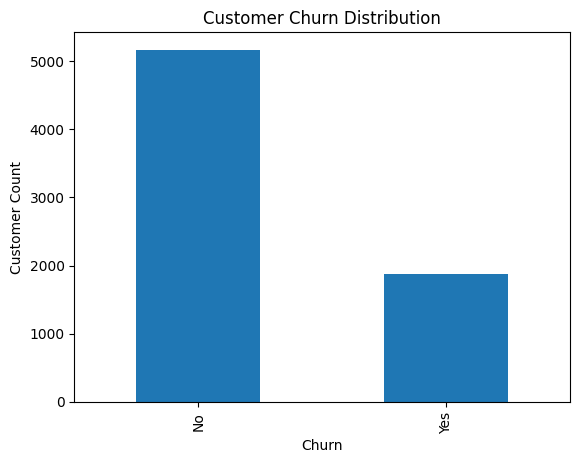

In [8]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")

plt.show()

In [9]:
pd.crosstab(df["Contract"],df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [10]:
round(
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100,
    2
)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [11]:
round(
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    ) * 100,
    2
)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [12]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

## Monthly Charges and Churn

Customers who churned have a higher average monthly charge.

- Retained customers: 61.27
- Churned customers: 74.44

This suggests that higher monthly charges may be associated with increased customer churn.

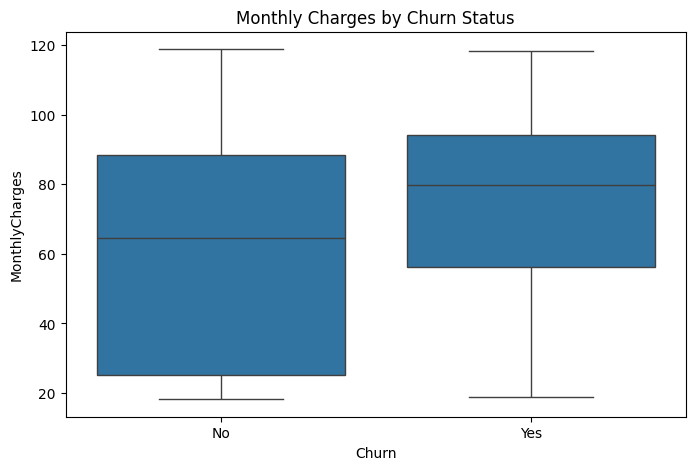

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")

plt.show()

## Monthly Charges vs Churn

The distribution of monthly charges differs between retained and churned customers.

Customers who churned generally pay higher monthly charges, with a noticeably higher median monthly fee compared to retained customers.

This may indicate that pricing plays a role in customer retention.

In [14]:
round(
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    ) * 100,
    2
)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


## Payment Method Impact on Churn

Customers using Electronic Check exhibit the highest churn rate (45.29%).

In contrast, customers using automatic payment methods show significantly lower churn rates.

This suggests that payment behavior may be strongly associated with customer retention.

In [15]:
round(
    pd.crosstab(
        df["TechSupport"],
        df["Churn"],
        normalize="index"
    ) * 100,
    2
)

Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


## Tech Support Impact on Churn

Customers without technical support exhibit a significantly higher churn rate (41.64%) compared to customers who receive technical support (15.17%).

This suggests that technical support services may contribute positively to customer retention.

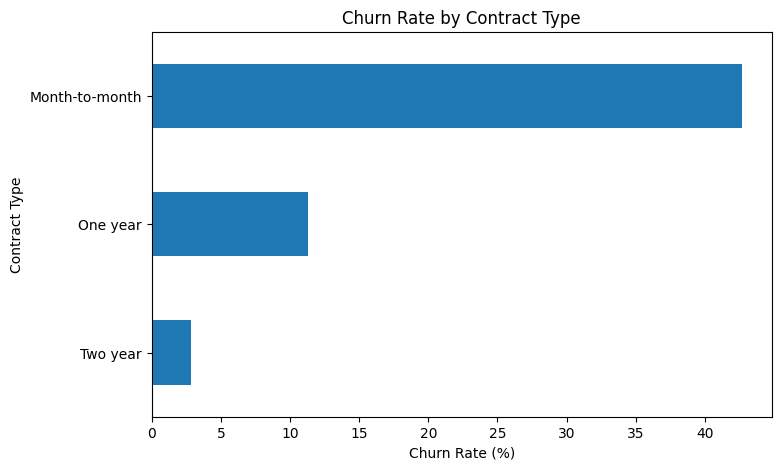

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Contract Type")

plt.show()

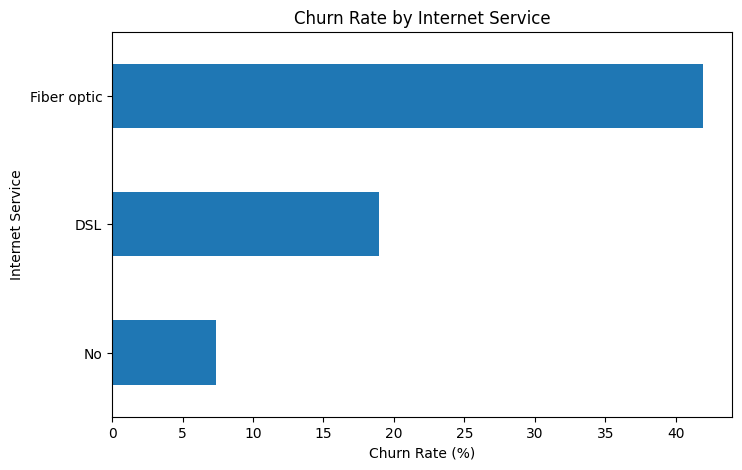

In [17]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Internet Service")

plt.show()

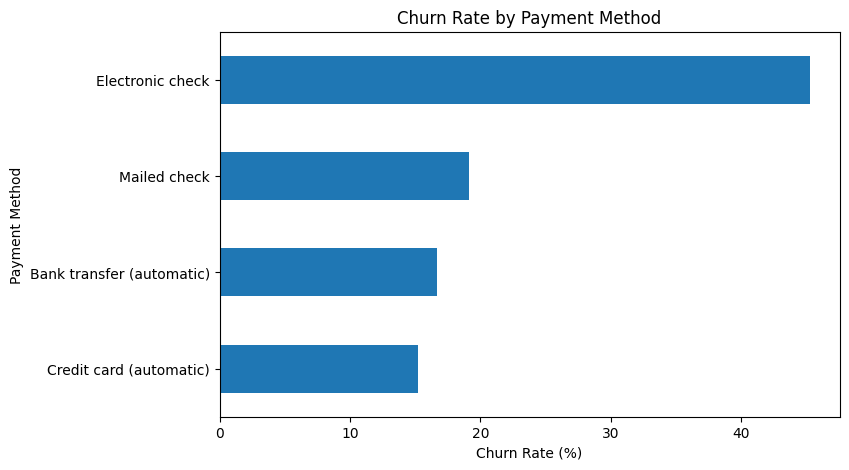

In [18]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

plt.show()

## Key Findings

### Contract Type
Customers with month-to-month contracts show the highest churn rate (42.71%), while customers with two-year contracts have the lowest churn rate (2.83%).

### Internet Service
Fiber optic customers have a significantly higher churn rate (41.89%) compared to DSL customers (18.96%).

### Payment Method
Customers using electronic checks show the highest churn rate (45.29%), while customers using automatic payment methods are less likely to churn.

### Online Security
Customers without Online Security service have a churn rate of 41.77%, compared to only 14.61% for customers who use the service.

### Partner Status
Customers without a partner are more likely to churn (32.96%) than customers with a partner (19.66%).

### Monthly Charges
Customers who churn tend to have higher monthly charges than customers who stay.

In [19]:
round(
    pd.crosstab(
        df["OnlineSecurity"],
        df["Churn"],
        normalize="index"
    ) * 100,
    2
)

Churn,No,Yes
OnlineSecurity,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


In [20]:
round(
    pd.crosstab(
        df["Partner"],
        df["Churn"],
        normalize="index"
    ) * 100,
    2
)

Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


In [21]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Conclusion

This analysis identified several factors strongly associated with customer churn.

Key findings include:

- Month-to-month contracts have the highest churn rate.
- Fiber optic customers churn more frequently than DSL customers.
- Customers using electronic checks are significantly more likely to leave.
- Customers without Online Security or Tech Support services show higher churn rates.
- Customers with higher monthly charges tend to churn more often.
- Customers without partners are more likely to leave the company.

These findings can help businesses design retention strategies, improve customer satisfaction, and reduce customer attrition.